<a href="https://colab.research.google.com/github/Morganjools/PRA3024/blob/main/PRA3024_2026_Cosmology_STUDENTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style='color:deepskyblue'> Cosmology MCMC notebook </span>

## <span style='color:deepskyblue'>Preliminaries</span>

In [39]:
# Install required packages (if not available on server, uncomment the lines below)

!pip3 install --upgrade pip
!pip3 install getdist
!pip3 install numpy
!pip3 install scipy
!pip3 install matplotlib


In [40]:
 #Load required packages
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.integrate as integrate

# import pylab
import getdist, IPython, time
from numpy import random

# from IPython.display import Image
from getdist import plots, MCSamples, loadMCSamples

# just for printing! calculations should be performed with machine precision
%precision 3

'%.3f'

(NB: Those equations that you will need to build your code are those $\boxed{\text{with a box around}}$)

## <span style='color:deepskyblue'> The $\Lambda$CDM Model </span>

The Lambda-Cold-Dark-Matter ($\Lambda$CDM) Model is our current "Standard" cosmological model. It postulates a Universe that behaves according to **General Relativity**, filled with **baryons** (protons, neutrons - the stuff we and stars are made of!), **Cold Dark Matter (CDM)** and a **Cosmological Constant** $\Lambda$.

The expansion of the Universe is best described in terms of the **scale factor** $a$ (the "radius" of the Universe, conventionally set to 1 today) and the **Hubble rate** $H$

$$
H \equiv \frac{\dot a}{a}
$$
Where the dot signifies a time derivative $\dot a \equiv da/dt $

The Einstein Equations in a **homogeneous and isotropic** Universe have an especially simple form and a special name, **Friedmann Equation**:

$$
H^2 = \frac{8\pi G}{3}\rho + \frac{k}{a^2}
$$

where $\rho$ is the total energy density of the Universe (at a certain time or size), and $k$ is a universal constant related to the [spatial curvature and shape of the Universe](https://en.wikipedia.org/wiki/Shape_of_the_universe#:~:text=The%20spatial%20curvature%20is%20related,indistinguishable%20spaces%20with%20different%20topologies.). In the $\Lambda$CDM model (and at late enough times), this additionally simplifies to

$$
\boxed{
H^2 = H_0^2\left(\Omega_\Lambda + \Omega_m a^{-3} + \Omega_k a^{-2}\right)
}
\qquad
\qquad
\boxed{
\Omega_m + \Omega_\Lambda + \Omega_k = 1
}
$$

$H_0$ is the value of the Hubble rate *today*, and the parameters $\Omega_m$, $\Omega_\Lambda$ and $\Omega_k$ are dimensionless quantities indicating how much of the present expansion of the Universe is due to (non-relativistic) matter, cosmological constant $\Lambda$, and spatial curvature $k$. Note that the three $\Omega$'s are *not independent* (their sum is 1) and that we grouped together the contribution of baryons and CDM,

$$
\Omega_m = \Omega_{\rm CDM} + \Omega_{\rm b}
$$

and that we have evidence that independent evidence that $\Omega_b \approx 5$\%. Note that only $\Omega_m \geq 0$ makes physical sense, while in principle both $\Omega_\Lambda$ and $\Omega_k$ can be negative.
In this consideration we are neglecting the contribution of the radiation which becomes negligable after the early stages of expansion.


The present Hubble rate is conventionally parametrised in terms of the dimensionless $h$:

$$
H_0 \equiv h\, \times 100 \left[\frac{ \,\text{km}}{\text{s Mpc}}\right]
$$

where Mpc = Megaparsec and [parsec](https://en.wikipedia.org/wiki/Parsec)  $pc = 3.086 \cdot 10^{16}$ m.

In essence, these equations give us the relation between *what exists in the Universe* and *how the Universe expanded*. Measure one, I can tell you the other. This is precisely what we aim to do!

Time to define the function $H(z)$. Don't forget to include the useful parameters as arguments of the function, and to define `parsec`.

## <span style='color:orange'> Excersise 1 </span>

Write your own code for the Hubble parameter as a function of redshift (z) note that $a = \frac{1}{1+z}$. Make a plot to see if your function works as expected.

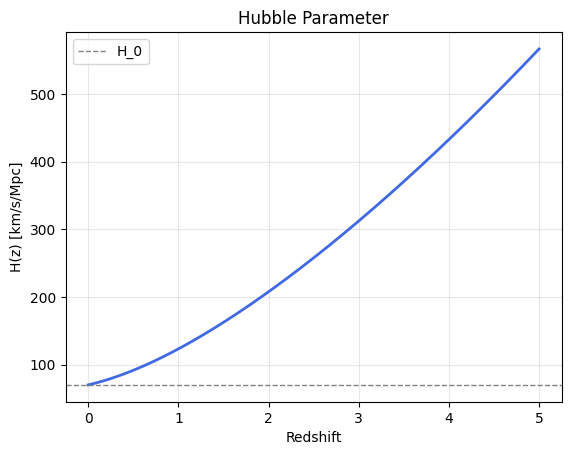

H(z=0) = 70.00 km/s/Mpc,  (expected 70.00)


In [41]:
parsec= 3.086e16 #[m]


#https://ubc-dsci.github.io/reproducible-and-trustworthy-workflows-for-data-science/lectures/900-functions-in-python.html
#Hubble Rate
def Hubble(omega_l, omega_m, h, z):
  H0=100*h
  omega_k= 1-omega_l-omega_m #Omega_k is derived from a universe with zero curvature
  H= H0*np.sqrt(omega_l + omega_m*(z+1)**3 + omega_k*(z+1)**2 ) #Replace a with z, using: a= 1/(1+z)
  return H

#Plotting the function to see if it works
omega_m= 0.3
omega_l= 0.7
h=0.7

#Now we create an array of 200 values for redshift values between 0 and 5 (z=5 corresponds to the universe being 1 Gyr oldhttps://ned.ipac.caltech.edu/level5/Sept14/Dunlop/Dunlop2.html)
z= np.linspace(0,5,500)

#Plotting
plt.plot(z, Hubble(omega_l, omega_m, h, z), color="royalblue", lw=2)
plt.axhline(100*h, color="gray", ls="--", lw=1, label="H_0")
plt.xlabel("Redshift")
plt.ylabel(r"H(z) [km/s/Mpc]")
plt.title(r"Hubble Parameter")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Other way to check if function works: setting z=0
print(f"H(z=0) = {Hubble(omega_l, omega_m, h, 0):.2f} km/s/Mpc,  (expected {100*h:.2f})")


#**Markdown Exercise 1**

The goal of this exercise was to create a python function for Hubble Parameter as a function of the redshift (z). It was then asked to make a plot of this function, using the current best values for the density parameters (https://astronomy.swin.edu.au/cosmos/*/Density+Parameter) and asuming that the baryonic density parameter is negligible, to make sure the function works as expected. The first step was to define parsec as the Hubble parameter is given in km/s/Mpc. The Hubble parameter function is dependent on the matter density (omega_m), on the cosmological constant (omega_l), on the redshift and on the present Hubble rate (H0), which is dependent on h.
The second step was to define the function of the Hubble parameter and the equations of the parameters needed for the Hubble parameter function; the curvature density (omega_k) and H0. Then the equation for the Hubble parameter was included, where the a was replaced with z, using the dependency relation. To see if the function works, the unknown parameters (omega_m, omega_l, h) inside the function were given specific values, based on the current best fit values. Additionally, as the Hubble parameter has to be plotted against the redshift, an array of values between 0 and 5 was created for z. z=5 correspond to roughly a 1 billion year old universe, but this can be changed if needed. Plotting the graph was pretty straightforward. A linear plot was used, as most hubble vs redshit plots are visualized that way (https://www.researchgate.net/figure/Hubble-parameter-as-a-function-of-the-redshift-for-different-values-of-the-parameter_fig2_258075001). Using log-scaling could work as well, in that case, a more exponential growth would have been shown.
Lastly, another way to show that the function works, is setting the redshift value to zero. This corresponds to the universe of today. The expected Hubble Parameter to get out of the function is H=H0= 70 km/s/Mpc.

**NEXT EXERCISE**

##  <span style='color:deepskyblue'>Supernovae Ia</span>

In order to track the expansion of the Universe, we will look at Supernovae type Ia observations. SNIa are formed when a *white dwarf* accretes matter from a companion until it reaches a critical mass of about $1.44 M_\odot$ (solar masses), after which it explodes **at always the same luminosity** $L_{\rm SN}$. Therefore, the observed [magnitude](https://en.wikipedia.org/wiki/Magnitude_(astronomy)) is only a function of their [**luminosity distance**](https://en.wikipedia.org/wiki/Distance_measures_(cosmology)) from Earth, defined as the ratio of the intrinsic luminosity $L_{\rm SNIa}$ and the measured *surface brightness* $\Phi$ (energy per unit time per unit area)

$$ d_L\equiv \frac{L_{\rm SN}}{4\pi \Phi} $$

While photons (light rays) travel from the distant SNIa to Earth, the Universe expands and the photons get redshifted, and this redshift is directly related to the size of the Universe when the photon was emitted compared to today:

$$ \frac{\lambda_{\rm obs}}{\lambda_{\rm em}} \equiv 1 + z_{\rm em} = \frac{1}{a_{\rm em}}$$

We can express the luminosity distance in terms of the Hubble rate:

$$
\boxed{
d_L(z) = \frac{c}{H_0}(1+z) \times
\begin{cases}
    \cfrac{1}{\sqrt{\Omega_k}} \,\sinh\left(\sqrt{\Omega_k}\,D(z)\right) & \Omega_k > 0
    \\[.5em]
    D(z) & \Omega_k = 0
    \\[.5em]
    \cfrac{1}{\sqrt{-\Omega_k}} \,\sin\left(\sqrt{-\Omega_k}\,D(z)\right) & \Omega_k < 0
\end{cases}
\qquad\qquad
D(z) \equiv H_0\int_0^z \frac{{\rm d}Z}{H(Z)}
}
$$

where $c$ is the speed of light: $c \simeq 2.998 \cdot 10^{5}$ km/s.

Clearly, there exists a relation between $d_L(z)$ and $H(z)$, so the luminosity distance is a useful measure of the Universe expansion history.

We can create the function `dL(z, h, Omega_m, Omega_Lambda)`. You can also pass the function `Hubble` as an argument: `dL(z, Hubble, Omega_m, Omega_Lambda)`. Additionally, you can create $D(z)$ for your convenience.

Note that you need to integrate the function $H(z)$, so write your own quick-and-easy numerical integrator, for example implementin the [trapezoidal rule](https://en.wikipedia.org/wiki/Trapezoidal_rule) or your favourite alternative, or [look up the pre-written methods](https://docs.scipy.org/doc/scipy/reference/tutorial/integrate.html). Make sure it returns $d_L$ in parsecs and that it uses $h$, which is $H_0$ measured in units of 100 km/s/Mpc!

## <span style='color:orange'> Excersise 2 </span>

Define a function that calculate the luminosty distance in flat ($\Omega_k = 0$) and both possitively and negatively curved  ($\Omega_k \neq 0$) spacetime.

In [42]:
from scipy import integrate

c = 2.998e5  #Speed of light [km/s]

#First D(z) is needed, as it is needed for dL
#D(z) is a function of z, and all parameters on which H is dependent (omega_m, omega_l and h)
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html
def D(z, omega_l, omega_m, h):
    H0 = 100 * h

    def integrand(Z):
        return H0 / Hubble(omega_l, omega_m, h, Z) #Rewrite the integration as: int(H0/ H(z) dZ), so it becomes dimensionless

    #Integrating from 0 to z
    #Quad function always gives an integration error that describes the precision of the integration
    result, int_error = integrate.quad(integrand, 0, z)
    return result

#Now define the function of luminosity distance dL
#It depends on D(z), which depends on the same parameters as H (h, z, omega_l, omega_m)
#Define omega_k, as conditions for the curvature are needed
def dL(z, omega_l, omega_m, h):
    H0 = 100 * h
    omega_k = 1 - omega_l - omega_m
    Dz = D(z, omega_l, omega_m, h)

    #Now set the conditions for the three curvature cases
    #Adding the functions that define the luminosity distance for all three conditions
    if omega_k > 0:
        distance = (1/np.sqrt(omega_k)) * np.sinh(np.sqrt(omega_k) * Dz)
    elif omega_k == 0:
        distance = Dz
    else: #When k<0
        distance = (1/np.sqrt(-omega_k)) * np.sin(np.sqrt(-omega_k) * Dz)

    #Now dL is calculated in H-units (km/s/Mpc), so it is converted to pc
    dL_Mpc = (c / H0) * (1 + z) * distance
    dL_pc  = dL_Mpc * 1e6
    return dL_pc

#To check if the function works
print(dL(0, omega_l, omega_m, h))  #Should be 0

0.0


#**Markdown Exercise 2**
The goal of the exercise was to define a function that calculates the luminosity distance for flat, positively curved and negatively curved spacetime. The function needed is given in the box above the code. Integration is needed to find the luminosity distance, so the integration package was imported, so the quad function can be used. In the function, the speed of light is needed, so that was defined first, in [km/s]. Then the first step is to creat a function for D(z). This is needed for all different curvature luminosity distances, so it is best to define this first. The integral can be rewritten with H0 inside the integral: D(z)= int((H0/H(z)))dZ. This is because H(z) already contains H0, so it can be divided out. The integral is now dimensionless. Using the quad-function and integrating from 0 to z, the result is obtained, with an additional error that describes the precision of the integral. The next step was to define the function for the luminosity distance, dL. dL depends on D(z), which depends on h, z, omega_m and omega_l. In this function omega_k, H0 and Dz are redefined. The three possible spacetime curvatures are defined with different functions, so these need to be set as conditions inside the dL function. This is done with an if-loop. The curvature is measured with omega_k. So if omega_k>0 (positive), the sinh function is used. Numpy sinh is used, as the input is an array (https://numpy.org/doc/2.1/reference/generated/numpy.sinh.html). If omega_k=0 (zero), then dl is equal to Dz. Lastly, the else-function is used. So if the curvature isn't larger than zero, or equal to zero, then this last function is used. So if omega_k<0 (negative), then the sin-function is used. Then the dL_Mpc is the value that is found from the function. Lastly, it is crucial that it is in pc units, so it is multiplied by 1e6, to find dL_pc.
Then, just to check if the function works, z is set to 0. With zero redshift, dL is expected to be zero.

**NEXT EXERCISE**

## <span style='color:deepskyblue'>The Union2.1 Compilation</span>

Our source of data is from [Union2.1](http://supernova.lbl.gov/Union/). It is a collection of $580$ SNIa, each observation is comprised of redshift $z$ and [distance modulus](https://en.wikipedia.org/wiki/Distance_modulus) $\mu$ (and corresponding errors $\delta\mu$), defined as the difference between the *apparent magnitude* $m$ and the *absolute magnitude* $M$:

$$
\boxed{
\mu(z) \equiv m(z) - M \equiv 5 \log_{10} \frac{d_L(z)}{10\,\text{pc}}
}
$$

Our goal today is to use SNIa measurements to constrain the parameters ($h, \Omega_\Lambda, \Omega_m$).

In essence, we can calculate for each redshift the theoretical value of $\mu$ using this equation with the expression for $d_L(z)$ and our model of choice $H(z)$ -- note that we will need to perform a numerical integral! -- and compare this value with observations. A different model would amount to changing the theoretical value of $H(z)$.

Let us start by importing and plotting the data:

In [43]:
#The data file didn't download with the other code, so I used this one provided on Canvas
import os, io, urllib.request

dataloc = "SCPUnion2.1_mu_vs_z.txt"  # local file

# If local file not found, download from Wayback Machine (original URL is down)
if not os.path.exists(dataloc):
    print("Local file not found, downloading from Wayback Machine...")
    url = "https://web.archive.org/web/2023id_/http://supernova.lbl.gov/Union/figures/SCPUnion2.1_mu_vs_z.txt"
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    response = urllib.request.urlopen(req)
    content = response.read().decode()
    with open(dataloc, 'w') as f:
        f.write(content)
    print("Downloaded and saved locally.")

# Read in data as numpy array.
# Format is [name, redshift, magnitude, magnitude error, and another number?]
data = np.genfromtxt(dataloc)

# Print the first line as an example. (Note that genfromtxt turns the names into 'Not A Number')
display(data[0])

array([      nan, 2.849e-02, 3.535e+01, 2.239e-01, 1.284e-01])

In [44]:
# Extract the redshifts (zs), distance modulus (dist_mod) and magnitude estimated errors (err_dist_mod)
# Data are in columns, so we either slice it by columns: arr[:,n]...
zs = data[:,1] # redshift
#print(len(zs))
# ...or transpose the array and then slice by row: arr_transposed[n]
distance_modulus = data.T[2] # distance modulus
error_distance_modulus = data.T[3] # errors on distance modulus = sigmas

print(zs)
print(distance_modulus)

[0.028 0.05  0.053 0.07  0.063 0.088 0.079 0.017 0.042 0.045 0.036 0.02
 0.101 0.027 0.075 0.026 0.05  0.031 0.016 0.015 0.031 0.025 0.024 0.026
 0.049 0.024 0.015 0.036 0.049 0.022 0.124 0.036 0.016 0.017 0.028 0.022
 0.016 0.023 0.036 0.019 0.018 0.032 0.024 0.017 0.054 0.017 0.028 0.017
 0.03  0.017 0.015 0.054 0.156 0.039 0.124 0.144 0.13  0.078 0.058 0.031
 0.041 0.015 0.022 0.016 0.036 0.017 0.031 0.022 0.016 0.025 0.03  0.028
 0.015 0.035 0.036 0.025 0.029 0.016 0.019 0.019 0.026 0.034 0.055 0.024
 0.034 0.034 0.026 0.021 0.032 0.022 0.033 0.034 0.042 0.058 0.021 0.04
 0.026 0.026 0.024 0.069 0.065 0.023 0.032 0.021 0.025 0.033 0.084 0.031
 0.033 0.042 0.068 0.015 0.023 0.049 0.043 0.019 0.031 0.021 0.028 0.034
 0.021 0.017 0.036 0.023 0.059 0.058 0.069 0.032 0.052 0.031 0.033 0.023
 0.015 0.032 0.064 0.032 0.021 0.022 0.032 0.015 0.019 0.027 0.038 0.025
 0.024 0.037 0.023 0.031 0.015 0.034 0.025 0.019 0.03  0.032 0.028 0.047
 0.018 0.08  0.024 0.015 0.028 0.045 0.033 0.075 0.02

In [45]:
# Let's look at the data, just for fun.
# We can look both at the raw data (distance modulus) or calculate the luminosity distance
# Note that Numpy allows us to manipulate whole arrays at once with something like:
#     array_2 = some_function_of(array_1)

# luminosity distance in pc
luminosity_distance_pc = 10. * 10.**(distance_modulus / 5.)

# and in Mpc
luminosity_distance_Mpc = luminosity_distance_pc / 10.**6

# and the error on that distance:
error_luminosity_distance_Mpc = 5. * (10.**((distance_modulus + error_distance_modulus)/5.-6.) - 10.**((distance_modulus - error_distance_modulus)/5.-6.))

print(luminosity_distance_pc)
print(luminosity_distance_Mpc)
print(error_luminosity_distance_Mpc)

[1.173e+08 2.170e+08 2.310e+08 3.086e+08 3.138e+08 4.424e+08 3.145e+08
 8.529e+07 1.851e+08 2.128e+08 1.517e+08 8.261e+07 4.913e+08 1.040e+08
 3.293e+08 1.248e+08 2.058e+08 1.288e+08 6.439e+07 6.140e+07 1.318e+08
 1.027e+08 9.857e+07 1.184e+08 2.220e+08 1.052e+08 6.612e+07 1.556e+08
 1.890e+08 9.345e+07 6.441e+08 1.459e+08 6.360e+07 7.003e+07 1.349e+08
 9.880e+07 6.859e+07 1.040e+08 1.686e+08 9.784e+07 7.392e+07 1.399e+08
 1.081e+08 6.318e+07 1.974e+08 7.512e+07 1.044e+08 7.114e+07 1.565e+08
 7.392e+07 6.803e+07 2.460e+08 7.012e+08 1.849e+08 5.813e+08 5.851e+08
 6.249e+08 3.439e+08 2.550e+08 1.534e+08 1.876e+08 6.359e+07 9.759e+07
 6.836e+07 1.575e+08 7.079e+07 1.335e+08 9.601e+07 5.820e+07 9.136e+07
 1.336e+08 1.271e+08 7.107e+07 1.569e+08 1.367e+08 1.125e+08 1.579e+08
 7.774e+07 1.022e+08 8.941e+07 1.371e+08 1.475e+08 2.099e+08 1.085e+08
 1.589e+08 1.474e+08 1.181e+08 8.553e+07 1.511e+08 9.648e+07 1.500e+08
 1.544e+08 1.906e+08 2.606e+08 8.384e+07 1.883e+08 1.192e+08 1.211e+08
 1.016

Recommendation: plot the data so you can see the luminosity distance and distance modulus as a function of the redshift

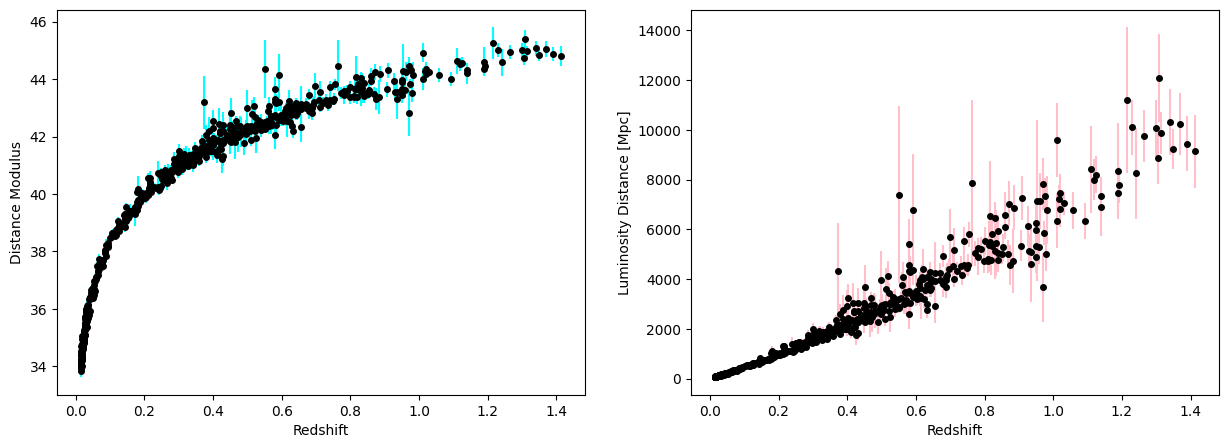

In [46]:
%matplotlib inline

plt.subplots(1, 2, figsize=(15, 5))

#Plot distance modulus versus redshift
plt.subplot(1, 2, 1)
plt.xlabel("Redshift")
plt.ylabel("Distance Modulus")
plt.errorbar(zs, distance_modulus, yerr=error_distance_modulus, fmt='o', color='black', ecolor='cyan', markersize=4)

#Plot luminosity distance versus redshift
plt.subplot(1, 2, 2)
plt.xlabel("Redshift")
plt.ylabel("Luminosity Distance [Mpc]")
plt.errorbar(zs, luminosity_distance_Mpc, yerr=error_luminosity_distance_Mpc, fmt='o', color='black', ecolor='pink', markersize=4)
plt.show()

#**Markdown Recommendation**
Plotting the data was straightforward, as the data was obtained previously. As the errors were given, errorbars could be plotted. Plotting these was obtained from: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.errorbar.html. The 'fmt' is how the data should be visualized on the plot. In this case, dots was the best possibility. If this is removed, the plots look like a mess, as the datapoints are connected by lines.

**NEXT EXERCISE**

## <span style='color:orange'> Excersise 3 </span>

Now also define a function to calculate the distance modulus using your previously defined luminosity distance function. Use these functions to plot the theoretical curves as a function of redshift and compare with the data. (Does the line go through the data points?)

In [47]:
#Equation of theoretical distance modulus from equation above
#The distance modulus is dependent on the same parameters as dL
def theor_distance_modulus(z, omega_l, omega_m, h):

    return 5 * np.log10(dL(z, omega_l, omega_m, h) / 10.)

#Checking the function for smallest redshift: z=0.1
#Should be somewhere around 35, according to first value of distance_modulus data
print(theor_distance_modulus(0.1, omega_l, omega_m, h))

38.3152592023126


Try your functions here. Make atleast two plots to check that for $\Omega_m = 0.3$, $\Omega_\Lambda = 0.7$ and $h =0.7$ your theory calculations of the luminosity distance and the distance modulus match okay to the data for redshifts ranging from ~0.1 to 2.

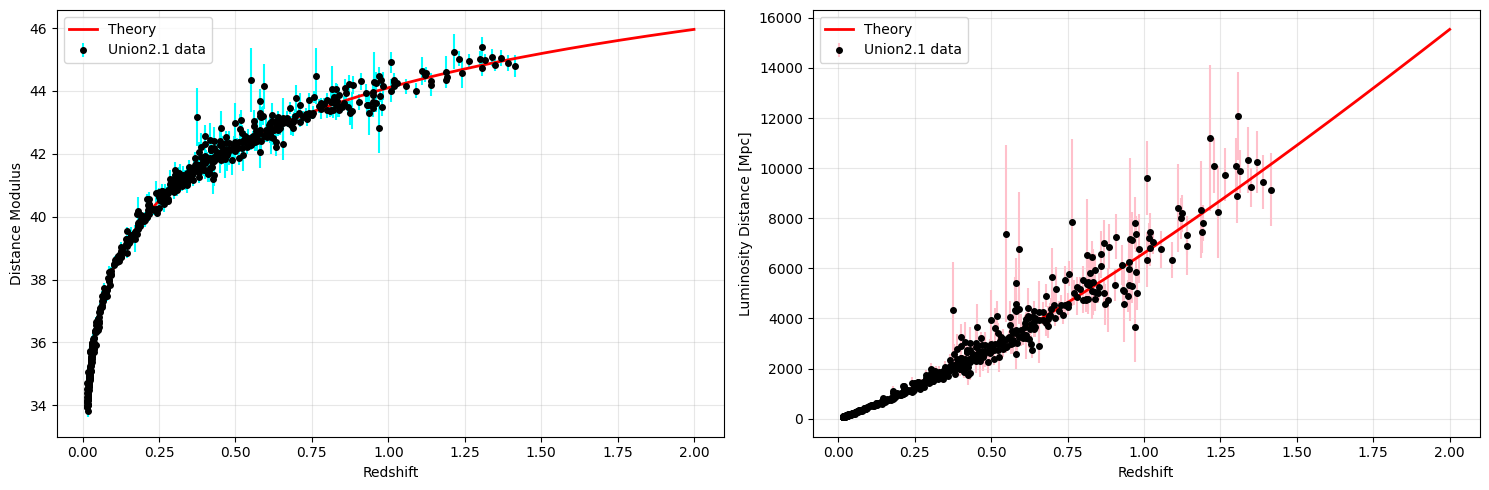

In [48]:
#Using the same values as above for the theoretical curve in the plot
omega_m = 0.3
omega_l = 0.7
h       = 0.7

#Now create arrays of the parameters for the plot
#z_theory is all values form zs data in 300 steps
#mu_theory is the value obtained from the function above for all z-values in the dataset from the equation, otherwise no plot would be possible
z_theory = np.linspace(0.1, 2, 300)
mu_theory = np.array([theor_distance_modulus(z, omega_l, omega_m, h) for z in z_theory])

#Plotting
plt.subplots(1, 2, figsize=(15, 5))

#Left plot is the distance modulus
plt.subplot(1, 2, 1)
plt.errorbar(zs, distance_modulus, yerr=error_distance_modulus, fmt='o', color='black', ecolor='cyan', markersize=4, label='Union2.1 data')
plt.plot(z_theory, mu_theory, color='red', linewidth=2, label='Theory')
plt.xlabel("Redshift")
plt.ylabel("Distance Modulus")
plt.legend()
plt.grid(True, alpha=0.3)

#Right plot is the luminosity distance
#Creating array for luminosity distance for all z-values in the data from the equation
dL_theory_Mpc = np.array([dL(z, omega_l, omega_m, h) for z in z_theory]) / 1e6

plt.subplot(1, 2, 2)
plt.errorbar(zs, luminosity_distance_Mpc, yerr=error_luminosity_distance_Mpc, fmt='o', color='black', ecolor='pink', markersize=4, label='Union2.1 data')
plt.plot(z_theory, dL_theory_Mpc, color='red', linewidth=2, label='Theory')
plt.xlabel("Redshift")
plt.ylabel("Luminosity Distance [Mpc]")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#**Markdown Exercise 3**


The goal of this exercise was to create a function for the distance modulus, using the function for the luminosity distance obtained in the previous exercise. The second goal was to make two plots. The first plot was of the distance modulus data against redshift and with a plotted line of the theoretical values, to see if it matches the data. The second plot was the same as the first, but then for the luminosity distance. The function was used to plot the theoretical values. The first step of the exercise was to create a function for the distance modulus. This function will be used to plot the theoretical value of h, omega_m and omega_l, to see how well the data fits. The function was obtained from the theory above, using np.log for arrays. The function was then checked with a z-value of 0.1, as this was the smallest value in the range. According to the dataset, the smallest distance_modulus value is around 35, so any value close to that would be considered okay. The next step was to plot the theoreticial distance modulus and luminosity distance, together with the data of the two, against redshift ranging from 0.1 to 2. The theoretical values that were used are: omega_m= 0.3, omega_l=0.7 and h=0.7. To plot, arrays are needed. So arrays for the redshift were created: 300 values between 0.1 and 2. Additionally, an array was made for the theoretical distance modulus, using the function and the array for redshift. This way, the theoretical curve is plotted for the three constant values given (0.3, 0.7 and 0.7) and the 300 values for redshift. The plotting is the same as done before, but now we plot the data and the curve in one plot. So the data are plotted, together with the errorbars, with the plt.errorbar function. And the curve is plotted with the plt.plot function (https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html).

**_Does the line go through the data points?_**

Yes, the line goes through the datapoints, as shown in the graphs. The theoretical values fit the datapoints very well.

**NEXT EXERCISE**

## <span style='color:deepskyblue'>Bayes' Theorem: Likelihood, Prior, Posterior (and Evidence...)</span>

The **conditional probability of A given that B is true** is denoted with $P(A|B)$ (read: *probability of A given B*).
Did A happen? Then B has probability $P(B|A)$ of happening.

[**Bayes' Theorem**](https://en.wikipedia.org/wiki/Bayes%27_theorem) is simply a reflection of the symmetry of the concept of joint probability:

$$
P(A|B)P(B) = P(B|A)P(A)
$$

In physics, our goal is often to determine how likely the values of some parameters $\theta$ are, given how well they reproduce the data $D$.
We write Bayes' theorem in the following equivalent form:

$$
P(\theta | D) = \frac{P(D|\theta)P(\theta)}{P(D)}
$$

The various terms conventionally take the names:

$$
\begin{aligned}
P(\theta | D) & && \text{Posterior}
\\
P(D | \theta)& && \text{Likelihood}
\\
P(\theta) & && \text{Prior}
\\
P(D) & && \text{Evidence}
\end{aligned}
$$

### <span style='color:deepskyblue'>Prior</span>

The *prior* quantifies our degree of prior belief in the model parameters. It can contain the results of previous experiments, or theoretical considerations (for instance, that certain parameters cannot be negative, etc.).

We can have *strong priors* about something - the Sun still existing at night, see the comic below - or not.
When we do *not* have compelling prior knowledge about a parameter, we generally use a *non-informative* prior probability distribution, most often related to the [uniform distribution](https://en.wikipedia.org/wiki/Continuous_uniform_distribution)

$$
\begin{aligned}
    \text{Uniform} & && \theta \in \text{Uniform}[\theta_{\rm min}, \theta_{\rm max}]
    \\
    \text{Log Uniform} & && \log\theta \in \text{Uniform}[\log\theta_{\rm min}, \log\theta_{\rm max}]
\end{aligned}
$$

You may sometimes hear that "the prior doesn't matter". While this is not strictly true, it is however true that in many instances the *likelihood* depends more dramatically on the parameters and will have a dominating contribution to the posterior. You are more than welcome to try different priors for the model parameters and see if and how your results change.

### <span style='color:deepskyblue'>Likelihood</span>

The measure of how well our model reproduces the data is the **likelihood** $\mathcal L$. For normal (=Gaussian), uncorrelated data $\mu_i$ with errors $\sigma_i$ ($i = \{1,580\}$), the likelihood is related to the famous [**chi-squared**](https://en.wikipedia.org/wiki/Chi-square_distribution) via

$$
P(D | \theta) \equiv \mathcal L = \exp\left(-\frac{\chi^2}{2}\right)
\qquad
\qquad
\boxed{
\chi^2 \equiv \sum_{i=1}^{580} \frac{\left(\mu_i^{(\rm theor)} - \mu_i^{(\rm obs)}\right)^2}{\sigma_i^2}
}
$$

A *high likelihood* corresponds to a *low chi squared*.

In principle, we could attack the problem brute-force: create a grid of values for $h$, $\Omega_m$, $\Omega_\Lambda$, calculate the likelihood for each combination, and create a profile for the likelihood.

In practical cases, however, this is not only sub-optimal but sometimes **impossible**. Think of complicated models with 20+ free parameters (this is not that unusual in physics, by the way). Even a very coarse grained grid of 100 values for each parameter would result in more than$10^{40}$ (!!!) different parameter combination to be tested. You can probably understand why this is undesirable.

### <span style='color:deepskyblue'>Evidence</span>

This is the tricky bit. The evidence, which is "*the probability of observing certain data*", is not something that is easy to evaluate or interpret. This looks like a serious limitation to finding the:


### <span style='color:deepskyblue'>Posterior</span>

What does the data tell us about the model parameters? The answer is the *posterior probability distribution*, often (but not necessarily) expressed as (average $\pm$ standard deviation)

$$
\theta_i = \bar\theta_i \pm \sigma_i
$$

In other words, the posterior tells us how likely it is for the model parameters to have certain values, *given that we observe the data* $D$.

*This is the final goal of our analysis!*

<br>

![title](http://1.bp.blogspot.com/-tTx4HDejSww/ULcTeK9_V_I/AAAAAAAAA8g/PCYOH-eXGbk/s1600/frequentists_vs_bayesians.png)
![title](https://i.redd.it/5r0hwixt0m931.jpg)

## <span style='color:deepskyblue'>Markov-Chain Monte Carlo</span>

Markov-Chain Monte Carlo techniques are a class of methods to sample a probability distribution $P(x)$ - in our case $P(\theta | D)$ - provided that we can calculate a density $\mathcal F(x)$ **that is proportional to it** - in our case $P(\theta)P(D|\theta)$ = likelihood $\times$ prior. Among these, a very popular one is the [**Metropolis-Hastings**](https://en.wikipedia.org/wiki/Metropolis%E2%80%93Hastings_algorithm) algorithm, which is what we will use.

Schematically, the algorithm works as follows:
* Start with an $n$-tuple of parameters $\theta_{\rm old} = \{\theta_1, \theta_2, \dots\}_{\rm old}$ (in our case $\theta = \{h,\Omega_m,\Omega_\Lambda\}$) and calculate the $\mathcal F_{\rm old}$
* Propose a new set of parameters $\theta_{\rm prop}$, calculate the new corresponding $\mathcal F_{\rm prop}$. How you propose the new parameters is not essential as long as the probability of going from one set of parameters to the next is the same as the inverse: $P(\theta_a \to \theta_b) = P(\theta_b \to \theta_a)$. For this, we normally take Gaussian displacements with some (relatively small) standard deviation.
* Compare the new and old likelihoods-priors:
    * If $\mathcal F_{\rm prop} > \mathcal F_{\rm old}$, accept the step: $\theta_{\rm new} = \theta_{\rm prop}$
    * Otherwise, accept with probability $P_{\rm accept} = \mathcal F_{\rm prop}/\mathcal F_{\rm old}$
* If accepted, $\theta_{\rm new} = \theta_{\rm prop}$ and record the step; otherwise, $\theta_{\rm new} = \theta_{\rm old}$ (no re-recording)
* Update $\theta_{\rm old} = \theta_{\rm new}$
* Repeat

The MC chain keeps going until the desired number of steps or, ideally, when a suitable convergence test, like for example the [Gelman-Rubin test](https://bookdown.org/rdpeng/advstatcomp/monitoring-convergence.html), is satisfied.
Today we will just set a limit to the total number of steps, but please feel free to implement and test your favourite convergence test!

Looking at equation (4), you can convince yourself that
$$
\frac{\mathcal L_a}{\mathcal L_b} = \exp\left(\frac{\chi_b^2 - \chi_a^2}{2}\right)
$$

(This is useful because $\chi^2$ can be large, so we want to avoid the likelihoods evaluating to `0.` -- computers don't like dividing by zero, unfortunately)

* Start with an $n$-tuple of parameters $\theta_{\rm old} = \{\theta_1, \theta_2, \dots\}_{\rm old}$ (in our case $\theta = \{h,\Omega_m,\Omega_\Lambda\}$) and the corresponding chi squared $\chi_{\rm old}^2$ (to be clear, for us this implies calculating a series of 580 integrals and comparing each with the observed values)
* Propose new parameters $\theta_{\rm prop}$ and calculate the corresponding chi squared $\chi_{\rm prop}^2$
* Draw a random number $r \in [0,1]$
* Accept the step if
$$
r < \exp\left(\frac{\chi_{\rm old}^2 - \chi_{\rm prop}^2}{2}\right) \frac{P(\theta)_{\rm prop}}{P(\theta)_{\rm old}}
$$
* If accepted, update $\theta_{\rm old} = \theta_{\rm prop}$, and record; otherwise, $\theta_{\rm new} = \theta_{\rm old}$ (no re-recording)
* Repeat

##  <span style='color:orange'> Excersise 4 </span>

Write your own code to perform a Monte Carlo Markov Chain. Note that your algorithm should be robust and converge to the correct parameters even for poor initial guesses.

In [50]:
from random import random
from random import gauss
import sys


#Define function for chi-squared
#mu_th (not the same as mu_theory, as z is different), is the theoretical distance_modulus. It is obtained from the theor_distance_modulus function on the given redshift range.
#distance_modulus is the observed, and is obtained from given data
def calculate_chi2(omega_l, omega_m, h, zs, distance_modulus, error_distance_modulus):

   #This is a loop that starts at 0 (otherwise Python would give an error)
   #len(zs) gives the total number of events in the data, so i takes all events (one event gives z, distance_modulus and error_distance_modulus)
   #Chi2 is the total
    chi2 = 0
    for i in range(len(zs)):
        mu_th = theor_distance_modulus(zs[i], omega_l, omega_m, h)
        chi2 += ((mu_th - distance_modulus[i]) / error_distance_modulus[i])**2 #Function for the chi squared
    return chi2


#These define how big of a step the chain takes each iteration when proposing new parameters
#So it is the current value with a standard deviation of 0.02
#If the step is too small, the acceptance rate is very high, but more data is explored
#If the step is too large, the proposed steps are large jumps with high chi-squared values, so they get rejected
step_omega_m = 0.02
step_omega_l = 0.02
step_h       = 0.02

#Some parameters for the chain
total   = 10000   #The total numbers of steps the chain will go over
N_steps = 0       #This counter counts how many steps get accepted, and is needed for the acceptance ratio

#This step is needed to double check if the parameters is the dataset are okay to use
#So omega_l and omega_m need to be between 0 and 1, as they cannot be negative and the best estimate is between these values (https://en.wikipedia.org/wiki/Cosmological_constant)
#Hubble constant's best value is 0.7, so a range of 0.5 to 1 is reasonable
#An all three parameters are within the bounds, 0.0 is returned. If not, then -np.inf, so impossible
def log_prior(omega_l, omega_m, h):

    if 0.0 < omega_m < 1.0 and 0.0 < omega_l < 1.0 and 0.5 < h < 1.0:
        return 0.0
    return -np.inf

filename = "MC_Chain_SNIa.txt"
file = open(filename, "w")
file.write("# Omega_m  Omega_L  h\n")

#  define Initial guess/value parameters
#Still using the same theoretical values
omega_m = 0.3
omega_l = 0.7
h       = 0.7

#Finding the chi-squared old, for the theoretical values, with the defined function
chi2_old = calculate_chi2(omega_l, omega_m, h, zs, distance_modulus, error_distance_modulus)

print("Progress:")
start = time.time()

#Now proposing new parameters and finding the chi-squared proposed
#So we are proposing new values in the range and starting a loop
for _ in range(total):

    #Propose new parameters using the steps specified earlier
    omega_m_prop = gauss(omega_m, step_omega_m)
    omega_l_prop = gauss(omega_l, step_omega_l)
    h_prop       = gauss(h,       step_h)

    #Now do the same as before, and check if the proposed values are inside the accepted ranges
    if log_prior(omega_l_prop, omega_m_prop, h_prop) == -np.inf:
        file.write(f"{omega_m:.4f}  {omega_l:.4f}  {h:.4f}\n")
        continue

    #Calculating the proposed chi_squared with the proposed values
    chi2_prop = calculate_chi2(omega_l_prop, omega_m_prop, h_prop, zs, distance_modulus, error_distance_modulus)

    #Now for the acceptance, using the function: r < exp((chi2_old - chi2_prop) / 2)
    r = random() #Number between 0 and 1
    if r < np.exp((chi2_old - chi2_prop) / 2):
       #If this is the case, then the step is accepted and the old parameters are replaced by the old:
        omega_m, omega_l, h = omega_m_prop, omega_l_prop, h_prop
        chi2_old = chi2_prop
        N_steps += 1 #If a step is accepted, the counter goes up by one, to find the total number of accepted steps

    # Record current parameters (accepted or not)
    file.write(f"{omega_m:.4f}  {omega_l:.4f}  {h:.4f}\n")

print(f"\nDone! Acceptance ratio = {N_steps/total:.3f}  ({N_steps}/{total} steps accepted)")
file.close()

end = time.time()
print(f"Time required: {end - start:.2f} s")

Progress:

Done! Acceptance ratio = 0.128  (1282/10000 steps accepted)
Time required: 337.77 s


In [51]:
chain = np.loadtxt("MC_Chain_SNIa.txt", comments='#')
omega_m_chain = chain[:, 0]
omega_l_chain = chain[:, 1]
h_chain       = chain[:, 2]

print(omega_m_chain)
print(omega_l_chain)
print(h_chain)

[0.3   0.3   0.3   ... 0.261 0.261 0.261]
[0.7   0.7   0.7   ... 0.706 0.706 0.706]
[0.7   0.7   0.7   ... 0.699 0.699 0.699]


After completion of the programme, your MC chain will (*hopefully*) look something like this:

`#Omega_m  Omega_L  h`

`0.297     0.703    0.698`

`0.285     0.715    0.701`

`0.288     0.712    0.699`

`...`

#**Markdown Exercise 4**

So the goal is to make a Monte Carlo Markov Chain, that walks through combinations of parameters, to find the best fit values for omega_m, omega_l and h. It was very difficult understanding the process of what had to happen. The first step was to define a function for the chi-squared, as given in the theory, for i {1,580}. This function is needed to find chi_old and chi_proposed. The next step was to propose new values for the old parameters. This was done by setting up step sizes of 0.02 between the old and new parameters. These steps cannot be too small, otherwise almost all new parameters would be accepted. It cannot be too big either, otherwise the new values would be rejected, due to high chi-squared values. So steps with standard deviation of 0,02 is okay, as the new values won't be too close to the old ones, but the jumps aren't too big either.
Then, the total number of steps for the chain was set to 10000 and a counter to find the number of accepted steps was started. These values are needed to find the acceptance ratio in the end.
Then the prior was used, so the theoretical value ranges, to filter the data, so only values and event with all three parameters within their ranges are used (https://en.wikipedia.org/wiki/Continuous_uniform_distribution). The ranges are quite large (0-1), so most values are accepted, but negative values for example, aren't.
Then the old chi-squared was found with the function defined and the theoretical values from before.
Then new steps had to be proposed. The 'gauss' function generates a random number from a gaussian distribution centered on the current value. This makes sure values close to the current value are proposed more often than values further away (https://machinelearningmastery.com/how-to-generate-random-numbers-in-python/: under _Random Gaussian Values_).
Then, the proposed chi-squared was calculated with the function and the proposed values.
After that, the accpetance function was defined. If the condition is met, the old values are replaced with the new and the step is added to the N_step counter. Lastly, the acceptence rate was calculated, by dividing N_step by the total.

**NEXT EXERCISE**

## <span style='color:deepskyblue'>Plotting: GetDist</span>

We will do the plots with [`GetDist`](https://getdist.readthedocs.io/en/latest/plot_gallery.html).

The plot gallery contains a lot of useful examples, you should be able to read them fairly easily and see which applies to your situation. Look for both (triangle) plots and for parameter estimation.

Note that many `GetDist` functions require arguments of type `MCSamples`; make sure you convert your lists accordingly.

##  <span style='color:orange'> Excersise 5 </span>

Use the GetDist functions in the example given underneath but with your **own** MCMC data to generate investigate the sampling of the MCMC.

Sample array shape: (9617, 4)
Removed no burn in
=== 1D Posteriors (1σ confidence intervals) ===
  0.2 < OmegaM < 0.345  at 68% CL
  0.583 < OmegaL < 0.828  at 68% CL
  0.695 < h < 0.704  at 68% CL
  -0.171 < Omegak < 0.209  at 68% CL


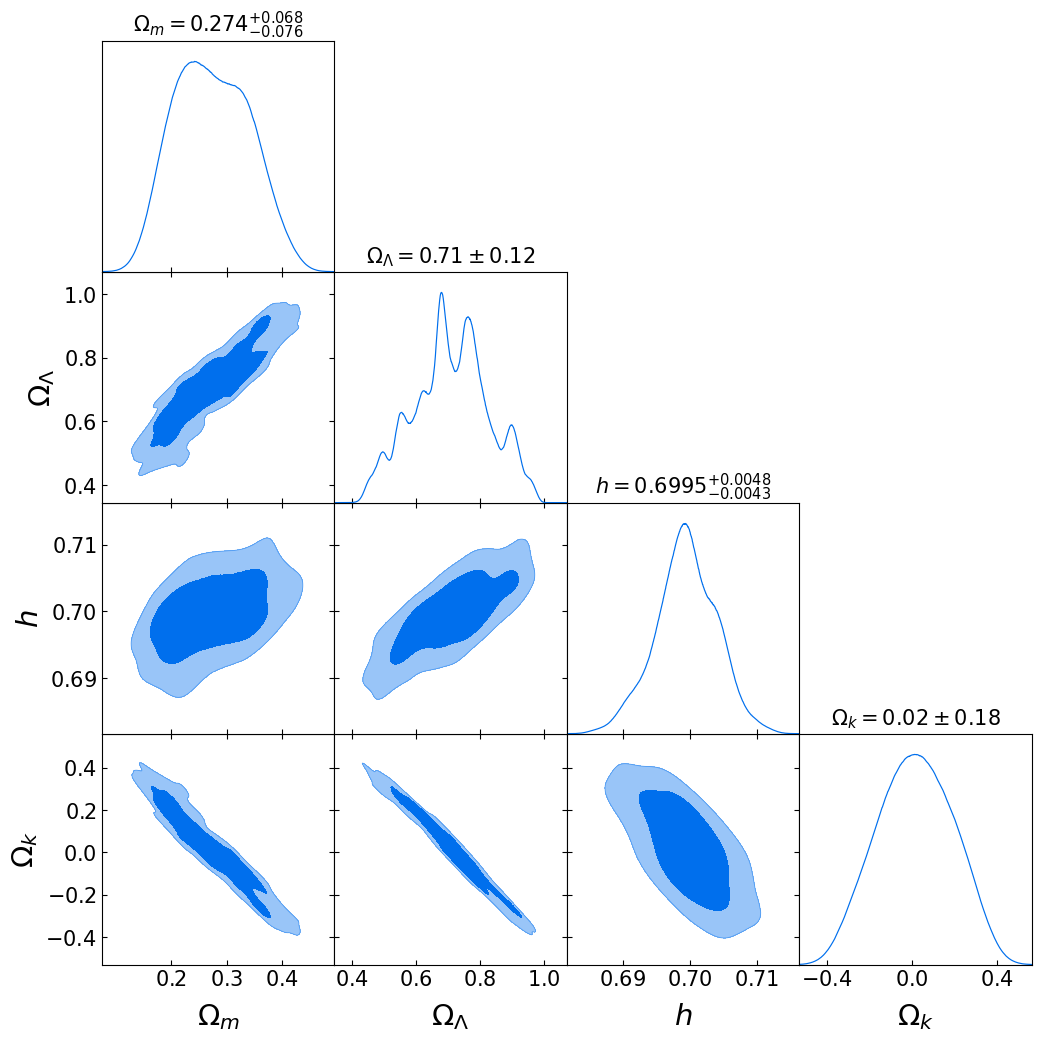

OmegaM	\Omega_m
OmegaL	\Omega_\Lambda
h	h
Omegak	\Omega_k



In [59]:
from getdist import MCSamples, plots

filename = "MC_Chain_SNIa.txt"
datafile = np.loadtxt(filename, skiprows=int(0.3 * N_steps))

#Extracting the desired parameters from the datafile
omegaM = datafile[:, 0]
omegaL = datafile[:, 1]
H_       = datafile[:, 2]

#Finding omega_k from the datafile with this equation
omegaK = 1. - omegaM - omegaL

#Define names and labels
my_labels = [r'\Omega_m', r'\Omega_\Lambda', r'h', r'\Omega_k']
my_names  = ['OmegaM', 'OmegaL', 'h', 'Omegak']
my_dim    = len(my_names) #This is the number of variables we are plotting

#Creating a higher dimensional array
my_samples = np.transpose(np.reshape([omegaM, omegaL, H_, omegaK], (my_dim, len(h_chain))))
print("Sample array shape:", np.shape(my_samples))

#Convert to MCSamples object so it can be used by GetDist
my_samples = MCSamples(samples=my_samples, labels=my_labels, names=my_names)

#Confidence interval of 1 sigma
conf_level = 0.6827

#Creating the upper and lower bounds for the confidence interval
print("=== 1D Posteriors (1σ confidence intervals) ===")
for nam in my_names:
    lo = round(my_samples.confidence(nam, (1. - conf_level) / 2., upper=False), 3)
    hi = round(my_samples.confidence(nam, (1. - conf_level) / 2., upper=True),  3)
    print(f"  {lo} < {nam} < {hi}  at {int(100*conf_level)}% CL")

#Plotting triangle corner plot (https://getdist.readthedocs.io/en/latest/plot_gallery.html)
j = plots.getSubplotPlotter(subplot_size=3)
j.settings.axes_labelsize = 22
j.settings.axes_fontsize  = 16
j.triangle_plot(my_samples, filled=True, title_limit=1)
plt.show()

#Parameter name check
print(my_samples.getParamNames())

#**Markdown Exercise 5**

This exercise was mostly given already, just had to edit it for my own datafile and preferences. From the triangle plot, we should be able to see the correlation between the parameters. In the table, the proposed values are obtained for omega_m, omega_l, omega_k and h. These values should be close to the theoretical values, and they are, fortunately. The confidence level for 1 sigma is 68%, this means that the value has a 68% change of being inside the 1 sigma range. Each parameter has two boundaries: 1 sigma above and 1 sigma beneath the value (https://en.wikipedia.org/wiki/68%E2%80%9395%E2%80%9399.7_rule). With this confidence interval, it cuts of the upper and lower 16% ((1-0.68)/2). This keeps the central 68% of the chain samples. However, you could also use 2 or 3 sigma's. This increases the probability of the value being inside the range.
The triangle plot describes the correlation between the parameters. At the top, the expected values are visualized with the uncertainties. The triangle plot is basically a heat map that explains how the parameters are connected. The diagonal plots show the fitting of the parameters to the mean value on both sides.

**NEXT EXERCISE**

##  <span style='color:orange'> Excersise 6 </span>

Show the curves for $d_L$ and/or $\mu$ as a function of redshift using the best fit parameters determined using your MCMC code, so you will need to make use of your earlier defined functions for $d_L$ and $\mu$ . Check if this correctly reproduces the data. Additionally, provide an extimate on the error and plot the corresponding confidence intervals based on the sample that your MCMC code produces.

Best fit values
h = 0.699
Omega_m = 0.274
Omega_L = 0.710
Omega_k = 0.016
The 1sigma confidence intervals
h = 0.699  [0.695, 0.704]
Omega_m = 0.274  [0.200, 0.345]
Omega_L = 0.710  [0.583, 0.828]


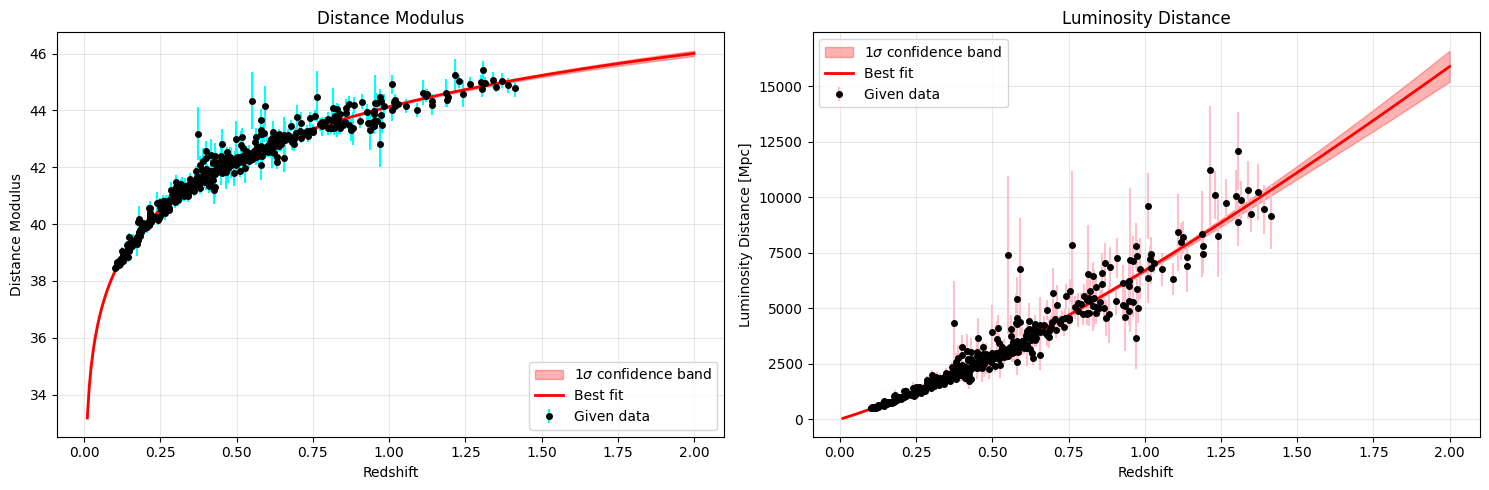

In [64]:
#Determining the best fit values for h, omega_l and omega_m, by taking the mean value of MCMC datafile (https://numpy.org/doc/stable/reference/generated/numpy.mean.html)
h_best       = np.mean(H_)
Omega_M_best = np.mean(omegaM)
Omega_L_best = np.mean(omegaL)

#Printing just to see
print("Best fit values")
print(f"h = {h_best:.3f}")
print(f"Omega_m = {Omega_M_best:.3f}")
print(f"Omega_L = {Omega_L_best:.3f}")
print(f"Omega_k = {1 - Omega_M_best - Omega_L_best:.3f}")

#Getting confidence intervals from MCMC samples, based on the given example
h_min       = my_samples.confidence('h', (1. - conf_level) / 2., upper=False)
h_max       = my_samples.confidence('h', (1. - conf_level) / 2., upper=True)
Omega_M_min = my_samples.confidence('OmegaM', (1. - conf_level) / 2., upper=False)
Omega_M_max = my_samples.confidence('OmegaM', (1. - conf_level) / 2., upper=True)
Omega_L_min = my_samples.confidence('OmegaL', (1. - conf_level) / 2., upper=False)
Omega_L_max = my_samples.confidence('OmegaL', (1. - conf_level) / 2., upper=True)

#Printing just to see
print("The 1sigma confidence intervals")
print(f"h = {h_best:.3f}  [{h_min:.3f}, {h_max:.3f}]")
print(f"Omega_m = {Omega_M_best:.3f}  [{Omega_M_min:.3f}, {Omega_M_max:.3f}]")
print(f"Omega_L = {Omega_L_best:.3f}  [{Omega_L_min:.3f}, {Omega_L_max:.3f}]")

#Using the theoretical z-values from zs data, as done before.
z_theory = np.linspace(0.01, 2.0, 300)

#Best fit curves, this is the same as done in previous exercises, but renamed as best fit
mu_best = np.array([theor_distance_modulus(z, Omega_L_best, Omega_M_best, h_best) for z in z_theory])
dL_best = np.array([dL(z, Omega_L_best, Omega_M_best, h_best) for z in z_theory]) / 1e6

#Creating the shaded confidence band
#The idea is to obtain 200 random parameter sets from the chain
N_draws  = 200
n_chain  = len(h_chain)

#These are grids with shape (200,300), so 200 rows for the sets and 300 columns for the redshift values
mu_draws = np.zeros((N_draws, len(z_theory)))
dL_draws = np.zeros((N_draws, len(z_theory)))

#With random.randint 200 random rows form the chain are chosen
#h_s, om_s and ol_s are the parameter values from the random rows
#Then 200 slightly different curves are created, and they all represent plausible sets of parameters
for i in range(N_draws):
    idx = np.random.randint(0, n_chain)
    h_s, om_s, ol_s = H_[idx], omegaM[idx], omegaL[idx]
    mu_draws[i] = np.array([theor_distance_modulus(z, ol_s, om_s, h_s) for z in z_theory]) #These are the functions from before
    dL_draws[i] = np.array([dL(z, ol_s, om_s, h_s) for z in z_theory]) / 1e6

#Creating the 1sigma confidence band; https://numpy.org/devdocs/reference/generated/numpy.percentile.html
#1-sigma band, so finding the middle 68%
mu_lo, mu_hi = np.percentile(mu_draws, 16, axis=0), np.percentile(mu_draws, 84, axis=0)
dL_lo, dL_hi = np.percentile(dL_draws, 16, axis=0), np.percentile(dL_draws, 84, axis=0)

#With the mask function the data can be filtered to a specific range, in this case 0.1-2 (https://www.w3schools.com/python/pandas/ref_df_mask.asp)
#It can be applied to the distance modulus and luminosity distance, so they only apply for redshifts within this range
mask = (zs >= 0.1) & (zs <= 2.0)

#Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#Left plot is the distance modulus
axes[0].errorbar(zs[mask], distance_modulus[mask], yerr=error_distance_modulus[mask], fmt='o', color='black', ecolor='cyan', markersize=4, label='Given data')
axes[0].fill_between(z_theory, mu_lo, mu_hi, color='red', alpha=0.3, label=r'1$\sigma$ confidence band') #The confidence band (https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.fill_between.html)
axes[0].plot(z_theory, mu_best, color='red', linewidth=2, label='Best fit')
axes[0].set_xlabel("Redshift")
axes[0].set_ylabel(r"Distance Modulus")
axes[0].set_title("Distance Modulus")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#Right plot is the luminosity distance
axes[1].errorbar(zs[mask], luminosity_distance_Mpc[mask], yerr=error_luminosity_distance_Mpc[mask], fmt='o', color='black', ecolor='pink', markersize=4, label='Given data')
axes[1].fill_between(z_theory, dL_lo, dL_hi, color='red', alpha=0.3, label=r'1$\sigma$ confidence band') #The confidence band (https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.fill_between.html)
axes[1].plot(z_theory, dL_best, color='red', linewidth=2, label='Best fit')
axes[1].set_xlabel("Redshift")
axes[1].set_ylabel(r"Luminosity Distance [Mpc]")
axes[1].set_title("Luminosity Distance")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#**Markdown Exercise 6**

The goal of this exercise was to plot the given data, as done before, but to add a confidence band from the MCMC data, to see how well it fits. The difficulty in this exercise was obtaining the confidence bands. First the best fit values were determined by taking the mean of the parameter from the MCMC datafile. Then, the confidence interval was calculated, using the example given. The obtained values were very close to the theoretical values, which is expected. After that, the given data was plotted, as done in previous exercises. It was done on the 0.1-2 redshift range. To create the confidence band, 200 random rows from the data file were selected. mu_draws and dl_draws are arrays calculated from functions from the starting exercises and the parameters of the 200 random rows and the redshifts.
So now there are 200 plausible parameter combinations. However, the curves need to correlate with the 68% confidence interval. So from these 200 combinations, the 1 sigma confidence interval was calculated, by removing the upper and lower bounds. Lastly, the data, the theoretical curve and the confidence band were plotted.

From the plots, it becomes clear that the MCMC values correlate well with the theoretical values. The confidence band for the distance modulus is more narrow than the band for luminosity distance. This means that there is more uncertainty in the parameters for the luminosity distance. However, it is still a good fit.

**END**